# 1. Imports

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedBaggingClassifier

# 2. Load the dataset (with features)

In [3]:
df = pd.read_csv("../data/BLE_FE.csv")
df = df.drop(columns='window_start')

In [4]:
df.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count,location
0,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
1,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
2,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7,cafeteria
3,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9,cafeteria
4,0,0,0,136,17,0,34,0,47,0,...,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11,cafeteria


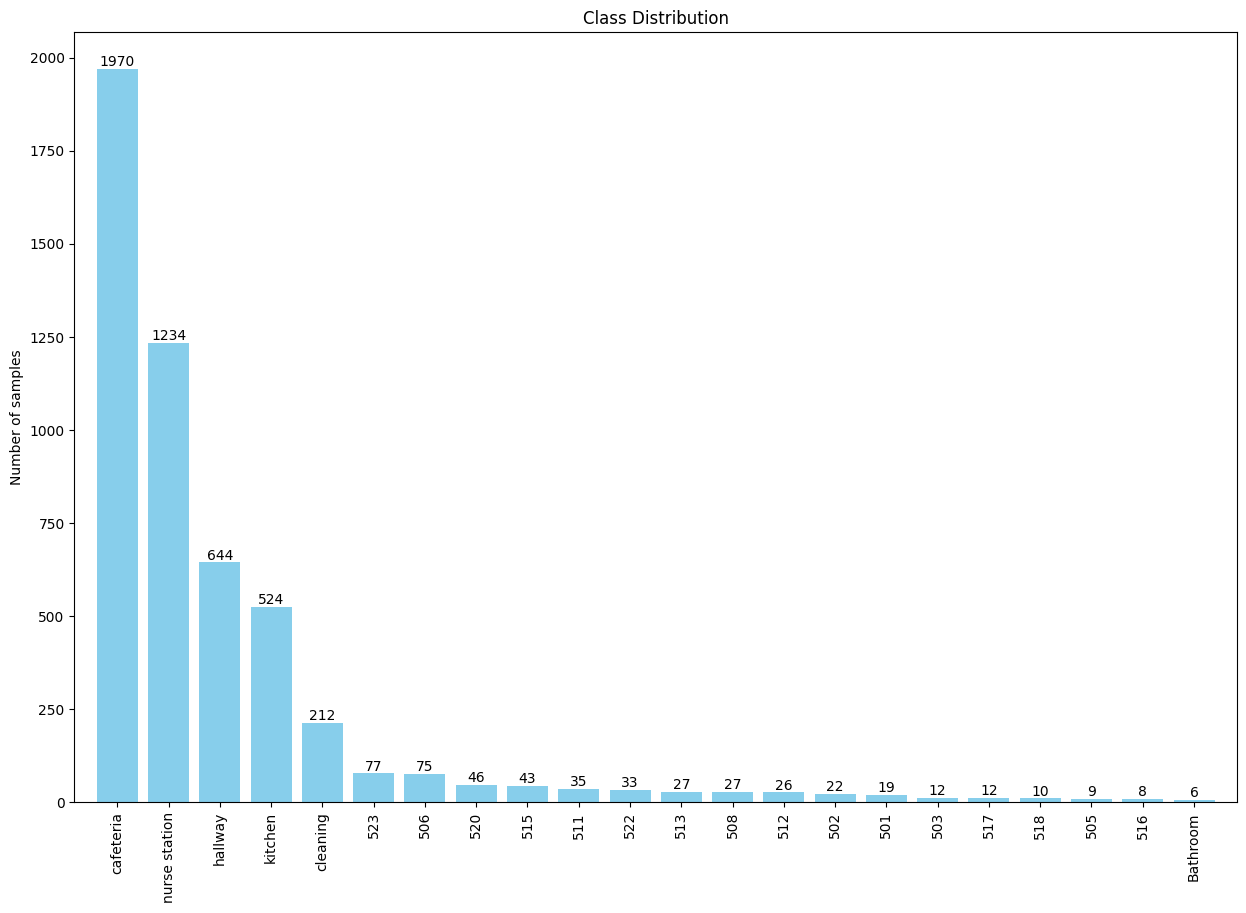

In [ ]:
distribution = df['location'].value_counts()

plt.figure(figsize=(15, 10))

bars = plt.bar(distribution.index, distribution.values, color='skyblue', width=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:}', ha='center', va='bottom')

plt.xticks(rotation=90)
plt.margins(x=0.02)
plt.ylabel('Number of samples')
plt.title('Class Distribution')
plt.tight_layout()
plt.savefig("../figs/class_distribution.png")
plt.show()

In [7]:
percentages = df['location'].value_counts(normalize=True) * 100
print(percentages)

location
cafeteria        38.848353
nurse station    24.334451
hallway          12.699665
kitchen          10.333268
cleaning          4.180635
523               1.518438
506               1.478998
520               0.907119
515               0.847959
511               0.690199
522               0.650759
513               0.532439
508               0.532439
512               0.512719
502               0.433839
501               0.374680
503               0.236640
517               0.236640
518               0.197200
505               0.177480
516               0.157760
Bathroom          0.118320
Name: proportion, dtype: float64


In [8]:
y = df['location']

In [9]:
X = df.drop(columns='location')
X.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_std,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count
0,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
1,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
2,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7
3,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9
4,0,0,0,136,17,0,34,0,47,0,...,1.247755,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11


In [10]:
split_idx = int(0.8 * len(X))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

In [11]:
missing_classes = set(np.unique(y_train)) - set(np.unique(y_test))
print("Classes missing in test:", missing_classes)

Classes missing in test: {'511', '503', '516', '522', '520', '502', '512', '501'}


In [12]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
np.unique(y_train_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

In [13]:
y_test_encoded = le.transform(y_test)
np.unique(y_test_encoded)

array([ 3,  4,  5,  8,  9, 11, 12, 15, 16, 17, 18, 19, 20, 21])

In [92]:
class_counts = np.bincount(y_train_encoded)
class_freq = class_counts / class_counts.sum()

class_weights = {
    c: 1.0 / np.log(1.2 + class_freq[c])
    for c in range(len(class_counts))
}

sample_weights = np.array([class_weights[y] for y in y_train_encoded])

In [84]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", X.columns)
    ]
)

In [ ]:
rf = RandomForestClassifier(
    criterion='entropy',
    n_estimators=800,
    max_depth=15,            
    min_samples_leaf=3,      
    min_samples_split=20,
    max_features="sqrt",
    class_weight='balanced',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", rf)
])

pipeline.fit(X_train, y_train_encoded)

y_pred = pipeline.predict(X_test)

In [146]:
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    min_child_weight=15,   
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,        
    reg_lambda=2.0,
    objective="multi:softprob",
    tree_method="hist",
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

pipeline.fit(X_train, y_train_encoded, classifier__sample_weight=sample_weights)

probs = pipeline.predict_proba(X_test)
def confidence_smooth(probs, k):
    T, C = probs.shape
    smoothed = np.zeros_like(probs)
    conf = probs.max(axis=1)

    for t in range(T):
        start = max(0, t - k)
        end = min(T, t + k + 1)
        smoothed[t] = np.average(
            probs[start:end],
            axis=0,
            weights=conf[start:end]
        )

    return smoothed
k = 10
smoothed_probs = confidence_smooth(probs, k)
y_pred = smoothed_probs.argmax(axis=1)

KeyboardInterrupt: 

In [165]:
accuracy = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='macro')
precision = precision_score(y_test_encoded, y_pred, average='macro', zero_division=0.0)
recall = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0.0)

print(f"Accuracy: {accuracy:.2f}")
print(f"Macro F1 score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.27
Macro F1 score: 0.12
Precision: 0.12
Recall: 0.17


In [107]:
f1_per_class = f1_score(y_test_encoded, y_pred, average=None)
test_classes = np.unique(le.inverse_transform(y_test_encoded))
sorted_idx = np.argsort(f1_per_class)[::-1]
sorted_classes = [test_classes[i] for i in sorted_idx]
sorted_f1 = [f1_per_class[i] for i in sorted_idx]

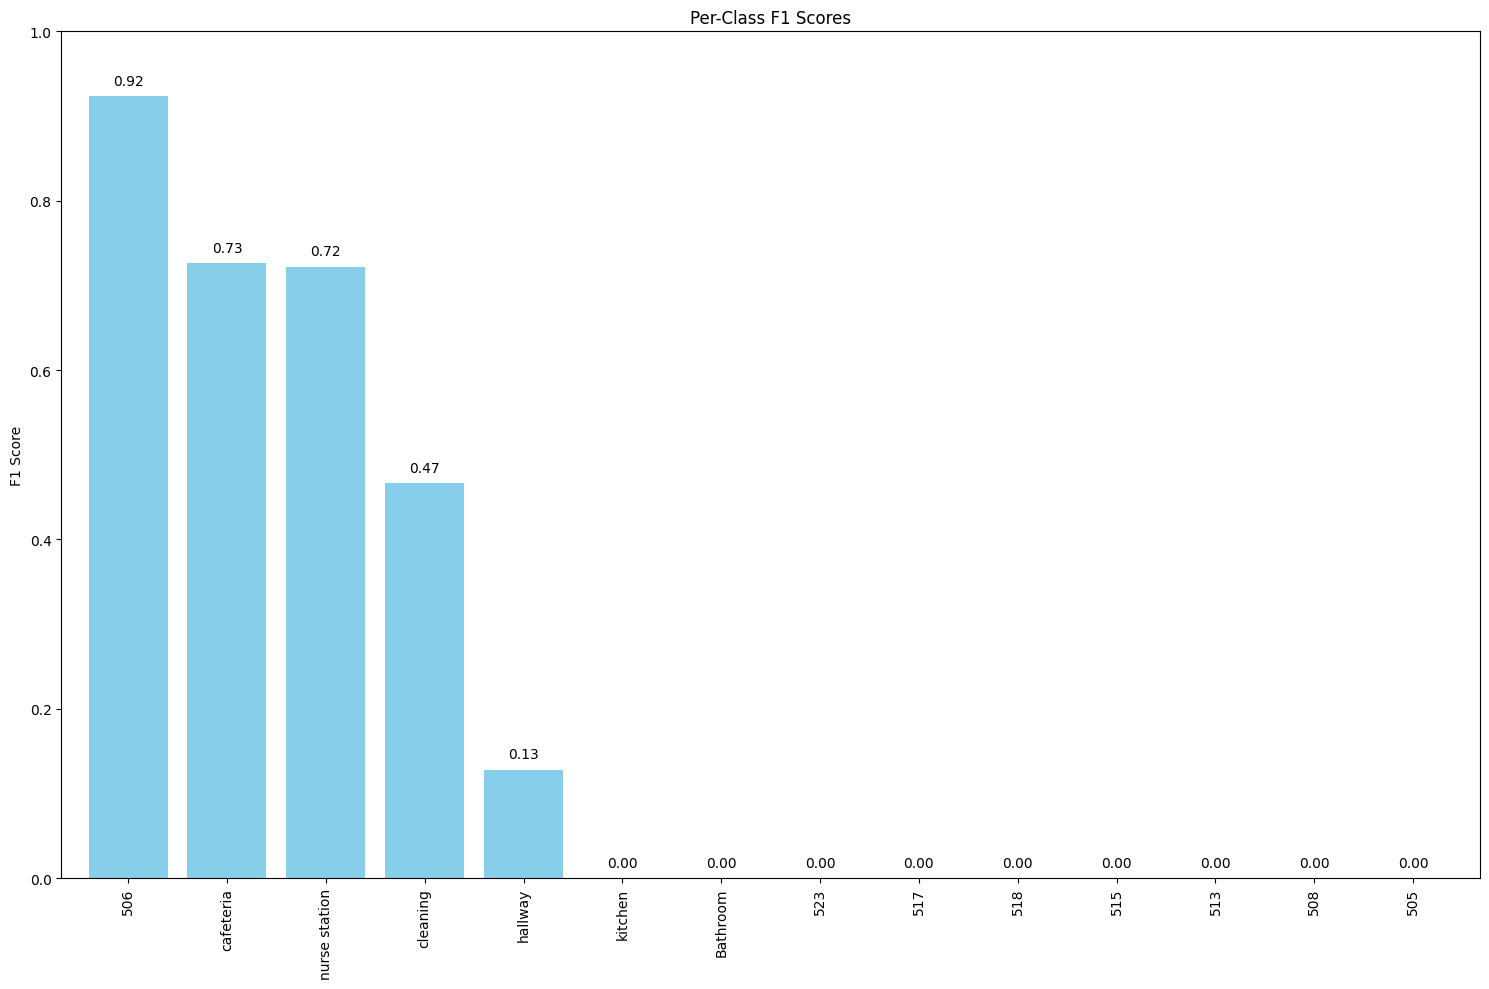

In [108]:
plt.figure(figsize=(15, 10))

bars = plt.bar(sorted_classes, sorted_f1, color='skyblue', width=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

plt.xticks(rotation=90)
plt.margins(x=0.02)
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('Per-Class F1 Scores')
plt.tight_layout()
plt.savefig("../figs/per_class_f1.png")

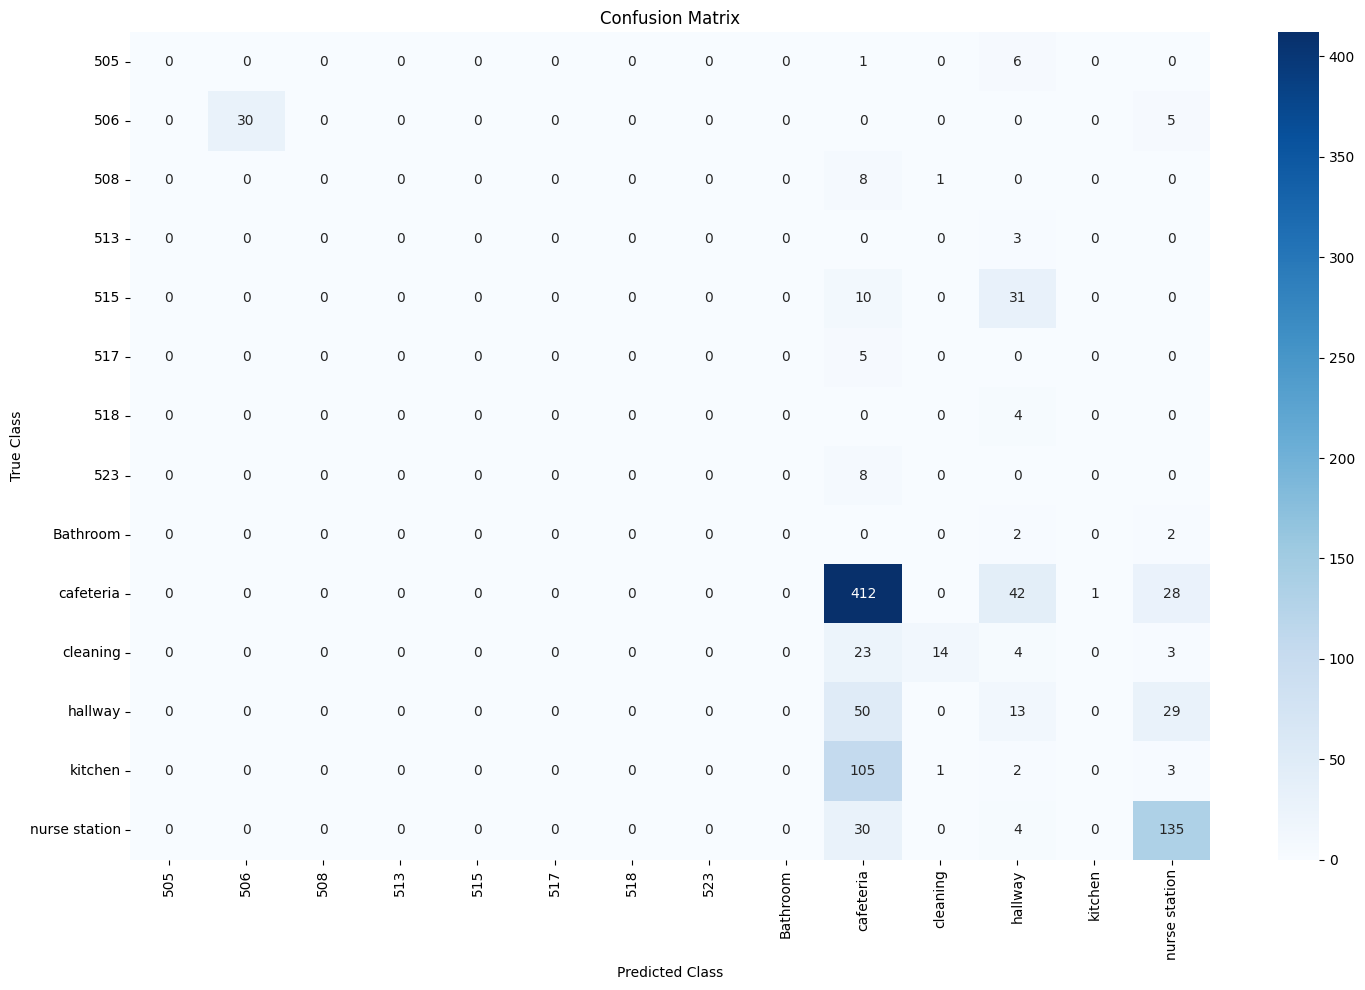

In [109]:
cm = confusion_matrix(y_test_encoded, y_pred, labels=np.unique(y_test_encoded))
cm_df = pd.DataFrame(cm, index=test_classes, columns=test_classes)
plt.figure(figsize=(15, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig("../figs/confusion_matrix.png")
plt.show()